In [3]:
from pydub import AudioSegment

# merge audio
audio = AudioSegment.empty()

for i in range(1, 11):
    path = f"../data/audio/poem1_versuri/vers{i}.wav"
    audio += AudioSegment.from_wav(path)

# Audio(audio.raw_data, rate=audio.frame_rate)
audio

In [12]:
from pathlib import Path

import numpy as np
from pydub import AudioSegment
from scipy.signal import hilbert, butter, sosfiltfilt, find_peaks

# ============================================================
# EASY-TO-TWEAK PARAMETERS
# ============================================================

lowpass_hz = 8.0
min_peak_distance_s = 0.20
prominence = 0.05


# ============================================================
# INPUT
# Can be either:
#   - a file path
#   - a pydub.AudioSegment
# ============================================================

audio_input = audio 

# Example alternative:
#
# audio_input = AudioSegment.from_file("poem.wav")


# ============================================================
# LOAD AUDIO
# ============================================================

if isinstance(audio_input, AudioSegment):
    audio = audio_input

elif isinstance(audio_input, (str, Path)):
    audio = AudioSegment.from_file(str(audio_input))

else:
    raise TypeError("audio_input must be a file path or pydub.AudioSegment")


# Convert to mono
audio = audio.set_channels(1)

fs = audio.frame_rate

# pydub -> NumPy
waveform = np.array(audio.get_array_of_samples(), dtype=np.float64)

# Normalize waveform
max_abs = np.max(np.abs(waveform))

if max_abs > 0:
    waveform /= max_abs


# ============================================================
# HILBERT ENVELOPE
# ============================================================

analytic_signal = hilbert(waveform)

envelope = np.abs(analytic_signal)


# ============================================================
# LOW-PASS FILTER THE ENVELOPE
# ============================================================

sos = butter(N=4, Wn=lowpass_hz, btype="lowpass", fs=fs, output="sos")

envelope_filtered = sosfiltfilt(sos, envelope)

# Remove possible tiny negative numerical values
envelope_filtered = np.maximum(envelope_filtered, 0)

# Normalize to 0–1
env_min = envelope_filtered.min()
env_max = envelope_filtered.max()

if env_max > env_min:
    envelope_filtered = (envelope_filtered - env_min) / (env_max - env_min)


# ============================================================
# FIND CANDIDATE STRESS PEAKS
# ============================================================

min_distance_samples = int(min_peak_distance_s * fs)

peaks, properties = find_peaks(
    envelope_filtered, distance=max(1, min_distance_samples), prominence=prominence
)


# ============================================================
# CONVERT PEAK LOCATIONS TO TIME
# ============================================================

time = np.arange(len(waveform)) / fs

stress_times = peaks / fs

stress_strength = envelope_filtered[peaks]


# ============================================================
# OUTPUT
# ============================================================

print(f"Sample rate: {fs} Hz")
print(f"Detected candidates: {len(peaks)}")
print()

for t, strength in zip(stress_times, stress_strength):
    print(f"{t:8.3f} s   " f"strength={strength:.3f}")
    if t > 3:
        print("...") 
        break

Sample rate: 44100 Hz
Detected candidates: 58

   0.082 s   strength=0.724
   0.368 s   strength=0.763
   0.705 s   strength=0.456
   0.930 s   strength=0.200
   1.130 s   strength=0.157
   2.269 s   strength=0.894
   2.751 s   strength=0.452
   3.104 s   strength=0.287
...


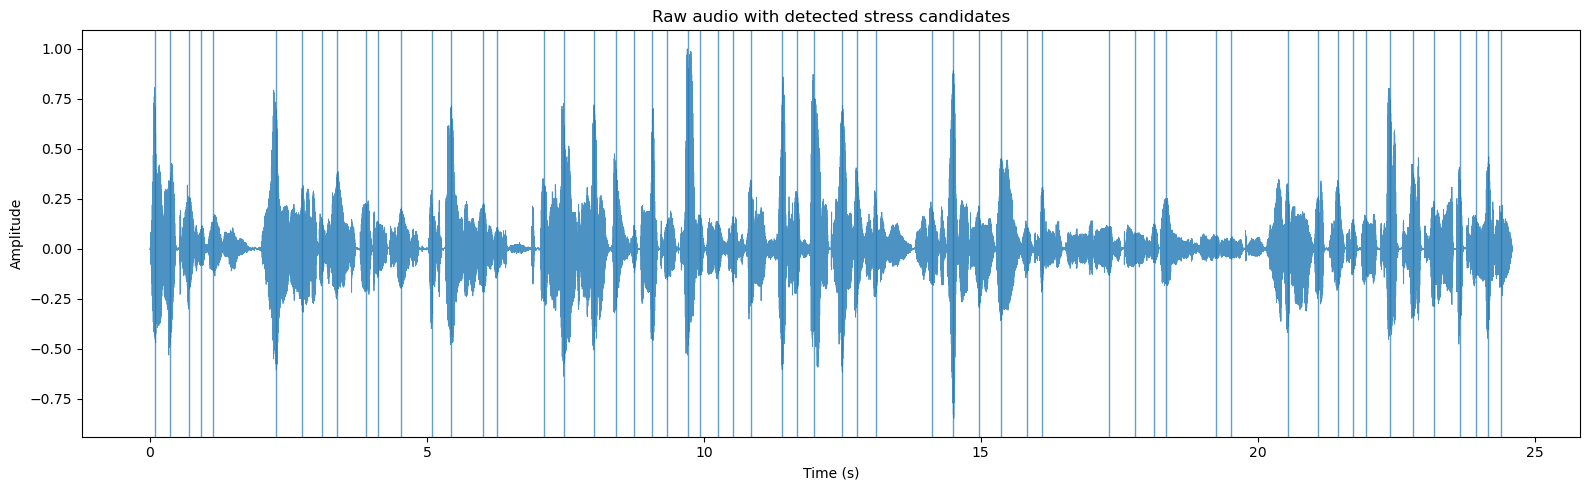

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))

# Raw / unfiltered audio waveform
plt.plot(time, waveform, linewidth=0.6, alpha=0.8, label="Raw audio")

# Vertical lines at detected stress candidates
for stress_time in stress_times:
    plt.axvline(x=stress_time, linewidth=1, alpha=0.7)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Raw audio with detected stress candidates")
plt.tight_layout()
plt.show()

In [15]:
from adapt_eeg.utils.ipynb_audio_visualization import waveform_player

In [16]:
waveform_player(audio, stress_times)